# [Improved V2] NFL Draft Prediction

Improvements over V1:
- **Position-relative percentile rank** for each performance column
- **Speed score**: combined Sprint_40yd + Shuttle + Agility_3cone
- **School target encoding**: school draft rate
- **Age relative to position**: age z-score within position group
- **Interaction features**: Height x Weight, Sprint x Vertical, Sprint x Broad_Jump

## 1. Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
import lightgbm as lgb

## 2. Load the Data

In [2]:
train = pd.read_csv('input/train.csv')
test  = pd.read_csv('input/test.csv')

print('Train shape:', train.shape)
print('Test shape: ', test.shape)
train.head()

Train shape: (2781, 16)
Test shape:  (696, 15)


,Id,Year,Age,School,Height,Weight,Sprint_40yd,Vertical_Jump,Bench_Press_Reps,Broad_Jump,Agility_3cone,Shuttle,Player_Type,Position_Type,Position,Drafted
0,0,2011,21.0,Lehigh,1.9050,140.160042,5.39,59.69,29.0,251.46,7.91,4.94,offense,offensive_lineman,OG,1.0
1,1,2011,24.0,Abilene Christian,1.8288,87.089735,4.31,101.60,16.0,332.74,NaN,NaN,offense,backs_receivers,WR,1.0
2,2,2018,21.0,Colorado St.,1.8542,92.986436,4.51,91.44,10.0,309.88,6.95,4.37,offense,backs_receivers,WR,1.0
3,3,2010,21.0,East Carolina,1.9304,148.778297,5.09,76.20,39.0,254.00,8.12,4.71,defense,defensive_lineman,DT,1.0
4,4,2016,21.0,California,1.8796,92.079251,4.64,78.74,NaN,281.94,7.13,4.20,offense,backs_receivers,WR,1.0


## 3. Feature Engineering

In [3]:
perf_cols = ['Sprint_40yd', 'Vertical_Jump', 'Bench_Press_Reps',
             'Broad_Jump', 'Agility_3cone', 'Shuttle']

# ── School target encoding (draft rate per school) ────────────────────────────
# Compute on train only, then map to test
school_draft_rate = train.groupby('School')['Drafted'].mean()
global_rate = train['Drafted'].mean()

def engineer_features(df, school_draft_rate, global_rate):
    df = df.copy()

    # ── V1 features ───────────────────────────────────────────────────────────
    # BMI
    df['BMI'] = df['Weight'] / (df['Height'] ** 2)

    # Missing-value flags
    for col in perf_cols:
        df[f'{col}_missing'] = df[col].isna().astype(int)

    # Number of missing performance tests
    df['n_missing'] = df[perf_cols].isna().sum(axis=1)

    # Position-relative z-scores
    for col in perf_cols:
        grp = df.groupby('Position')[col]
        df[f'{col}_pos_zscore'] = (df[col] - grp.transform('mean')) / (grp.transform('std') + 1e-6)

    # ── V2 features ───────────────────────────────────────────────────────────

    # 1. Position-relative percentile rank
    for col in perf_cols:
        df[f'{col}_pos_rank'] = df.groupby('Position')[col].rank(pct=True)

    # 2. Speed score (lower time = faster = better for sprint/shuttle/agility)
    #    Invert sprint/shuttle/agility so higher = better, then sum
    sprint_inv  = 1.0 / (df['Sprint_40yd']   + 1e-6)
    shuttle_inv = 1.0 / (df['Shuttle']        + 1e-6)
    agility_inv = 1.0 / (df['Agility_3cone']  + 1e-6)
    df['speed_score'] = sprint_inv + shuttle_inv + agility_inv

    # 3. School target encoding
    df['school_draft_rate'] = df['School'].map(school_draft_rate).fillna(global_rate)

    # 4. Age relative to position (z-score)
    age_grp = df.groupby('Position')['Age']
    df['age_pos_zscore'] = (df['Age'] - age_grp.transform('mean')) / (age_grp.transform('std') + 1e-6)

    # 5. Interaction features
    df['height_x_weight']   = df['Height'] * df['Weight']
    df['sprint_x_vertical'] = df['Sprint_40yd'] * df['Vertical_Jump']
    df['sprint_x_broad']    = df['Sprint_40yd'] * df['Broad_Jump']

    return df

train = engineer_features(train, school_draft_rate, global_rate)
test  = engineer_features(test,  school_draft_rate, global_rate)

print('Feature engineering done. Train shape:', train.shape)

Feature engineering done. Train shape: (2781, 42)


## 4. Preprocessing

In [4]:
# Encode categoricals
cat_cols = ['Player_Type', 'Position_Type', 'Position']
for col in cat_cols:
    le = LabelEncoder()
    combined = pd.concat([train[col], test[col]], axis=0).astype(str)
    le.fit(combined)
    train[col] = le.transform(train[col].astype(str))
    test[col]  = le.transform(test[col].astype(str))

print('Categorical encoding done.')

Categorical encoding done.


In [5]:
# Define features
base_num = ['Year', 'Age', 'Height', 'Weight',
            'Sprint_40yd', 'Vertical_Jump', 'Bench_Press_Reps',
            'Broad_Jump', 'Agility_3cone', 'Shuttle']

v1_features = ['BMI', 'n_missing'] + \
              [f'{c}_missing'    for c in perf_cols] + \
              [f'{c}_pos_zscore' for c in perf_cols]

v2_features = [f'{c}_pos_rank' for c in perf_cols] + \
              ['speed_score', 'school_draft_rate', 'age_pos_zscore',
               'height_x_weight', 'sprint_x_vertical', 'sprint_x_broad']

features = base_num + cat_cols + v1_features + v2_features

X      = train[features]
y      = train['Drafted']
X_test = test[features]

print(f'Total features: {len(features)}')

Total features: 39


## 5. LightGBM Model

In [6]:
params = {
    'objective':         'binary',
    'metric':            'auc',
    'learning_rate':     0.05,
    'num_leaves':        63,
    'min_child_samples': 20,
    'feature_fraction':  0.8,
    'bagging_fraction':  0.8,
    'bagging_freq':      5,
    'verbose':           -1,
    'n_jobs':            -1,
}

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
oof_preds  = np.zeros(len(X))
test_preds = np.zeros(len(X_test))

for fold, (tr_idx, val_idx) in enumerate(skf.split(X, y)):
    X_tr, X_val = X.iloc[tr_idx], X.iloc[val_idx]
    y_tr, y_val = y.iloc[tr_idx], y.iloc[val_idx]

    dtrain = lgb.Dataset(X_tr, label=y_tr)
    dval   = lgb.Dataset(X_val, label=y_val, reference=dtrain)

    model = lgb.train(
        params,
        dtrain,
        num_boost_round=1000,
        valid_sets=[dval],
        callbacks=[lgb.early_stopping(50, verbose=False),
                   lgb.log_evaluation(period=-1)],
    )

    oof_preds[val_idx] = model.predict(X_val)
    test_preds        += model.predict(X_test) / 5

    fold_auc = roc_auc_score(y_val, oof_preds[val_idx])
    print(f'Fold {fold+1}  AUC: {fold_auc:.5f}')

oof_auc = roc_auc_score(y, oof_preds)
print(f'\nOverall OOF AUC: {oof_auc:.5f}')

Fold 1  AUC: 0.83404
Fold 2  AUC: 0.87931
Fold 3  AUC: 0.85060
Fold 4  AUC: 0.81205
Fold 5  AUC: 0.85611

Overall OOF AUC: 0.84351


## 6. Feature Importance

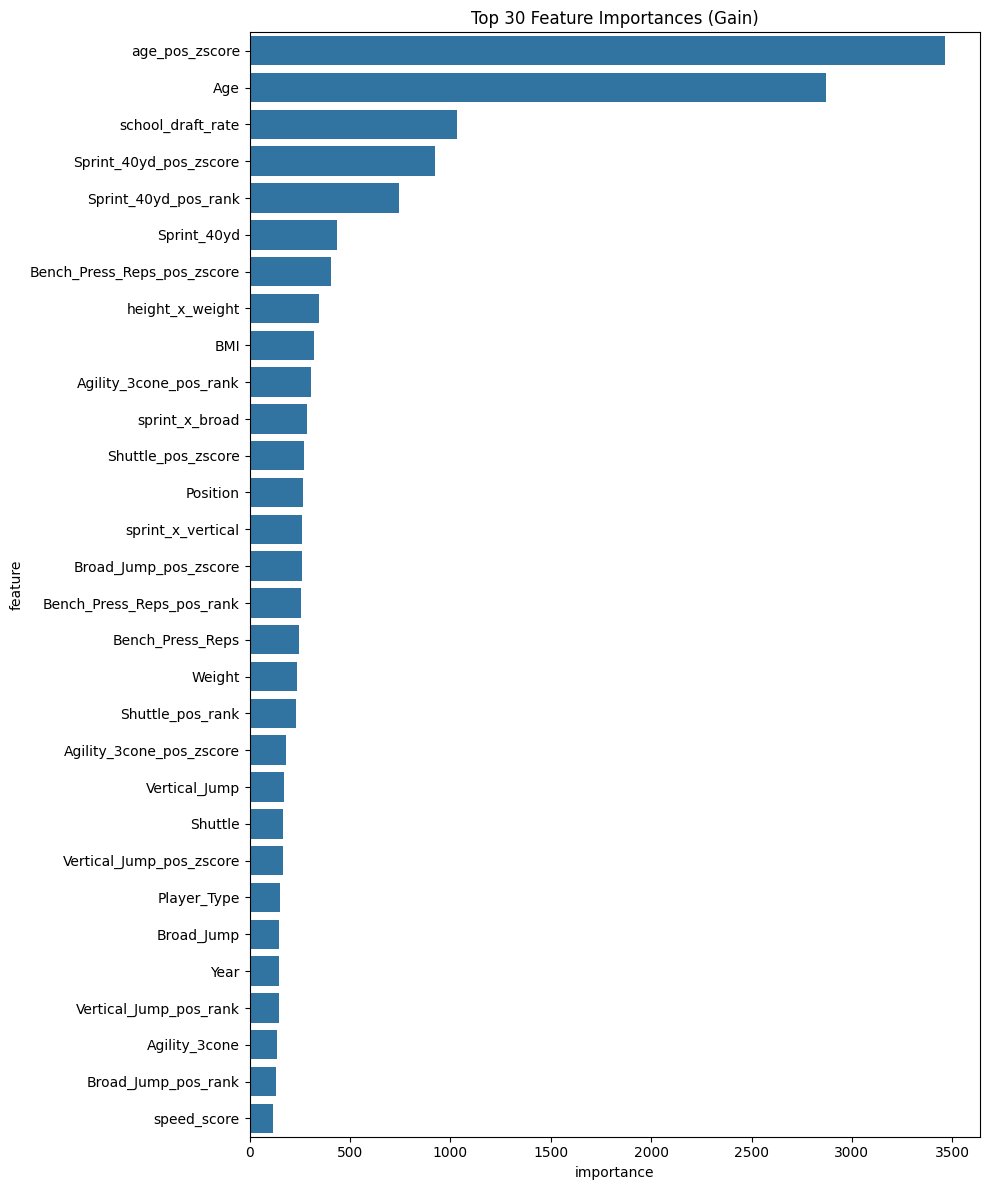

                        feature   importance
35               age_pos_zscore  3464.528556
1                           Age  2869.587629
34            school_draft_rate  1033.915048
21       Sprint_40yd_pos_zscore   923.593088
27         Sprint_40yd_pos_rank   746.831818
4                   Sprint_40yd   435.587513
23  Bench_Press_Reps_pos_zscore   406.828685
36              height_x_weight   343.782104
13                          BMI   320.771945
31       Agility_3cone_pos_rank   305.815083
38               sprint_x_broad   285.796462
26           Shuttle_pos_zscore   271.550456
12                     Position   264.102932
37            sprint_x_vertical   262.645878
24        Broad_Jump_pos_zscore   262.488132
29    Bench_Press_Reps_pos_rank   253.891467
6              Bench_Press_Reps   246.431516
3                        Weight   237.072029
32             Shuttle_pos_rank   231.077085
25     Agility_3cone_pos_zscore   181.173912


In [7]:
# Show feature importance from last fold model
importance = pd.DataFrame({
    'feature': features,
    'importance': model.feature_importance(importance_type='gain')
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 12))
sns.barplot(data=importance.head(30), x='importance', y='feature')
plt.title('Top 30 Feature Importances (Gain)')
plt.tight_layout()
plt.show()

print(importance.head(20).to_string())

## 7. Create the Submission File

In [8]:
submission = pd.read_csv('input/sample_submission.csv')
submission['Drafted'] = test_preds
submission.to_csv('submission_V2.csv', index=False)
print('submission_V2.csv saved!')
submission.head()

submission_V2.csv saved!


,Id,Drafted
0,2781,0.683417
1,2782,0.915778
2,2783,0.890845
3,2784,0.973517
4,2785,0.866751


## 8. Next Steps (V3)

- Hyperparameter tuning with Optuna
- Try CatBoost or XGBoost ensemble
- More cross-features based on feature importance above